<a href="https://colab.research.google.com/github/AngelDavidRuizB/Trabajos-IA-y-mini-Robots-Angel-David-Ruiz-Barbosa/blob/main/Ejercicios_semana_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 1

Entrenamiento de NAND completado (20000 épocas)

  TABLA DE VERDAD - NAND
  X1   X2  |  Salida   | Esperado | Correcto
  ----------------------------------------------
   0    0   |   0.9996   |    1     |  ✓
   0    1   |   0.9955   |    1     |  ✓
   1    0   |   0.9956   |    1     |  ✓
   1    1   |   0.0069   |    0     |  ✓

  Precisión: 4/4 = 100.0%

Entrenamiento de XOR completado (20000 épocas)

  TABLA DE VERDAD - XOR
  X1   X2  |  Salida   | Esperado | Correcto
  ----------------------------------------------
   0    0   |   0.0037   |    0     |  ✓
   0    1   |   0.9943   |    1     |  ✓
   1    0   |   0.9943   |    1     |  ✓
   1    1   |   0.0049   |    0     |  ✓

  Precisión: 4/4 = 100.0%



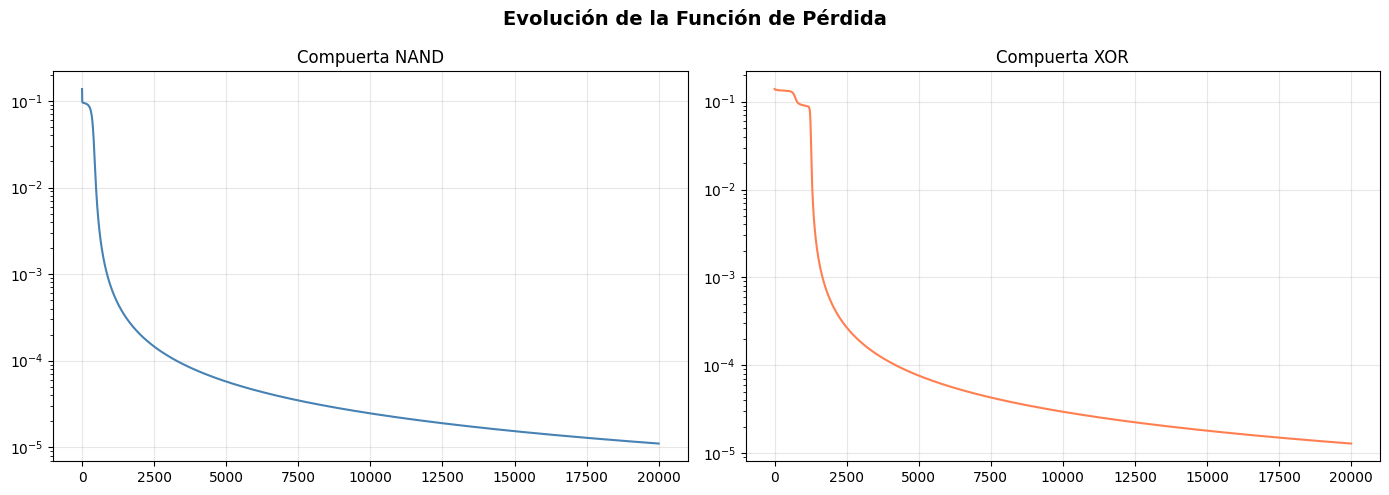

Gráfica guardada como: ejercicio1_perdida.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FUNCIONES BASE
# ============================================================

def sig(s):
    """Función de activación sigmoide"""
    return 1 / (1 + np.exp(-s))

def dSig(s):
    """Derivada de la sigmoide (para backpropagation)"""
    # σ'(z) = σ(z)(1 - σ(z))
    df = sig(s.T[0]) * (1 - sig(s.T[0]))
    ds = np.diag(df)
    return ds

def error(A_out, Yd):
    """Error entre salida de la red y el rótulo deseado"""
    return Yd - A_out

# ============================================================
# RED NEURONAL GENÉRICA CON 2 CAPAS OCULTAS (3 capas en total)
# Arquitectura: entrada → capa1 → capa2 → salida
# ============================================================

class RedNeuronal2CapasOcultas:
    def __init__(self, n0, n1, n2, n3, nombre="Red"):
        self.nombre = nombre
        np.random.seed(42)
        self.W1 = np.random.randn(n1, n0) * 0.5
        self.b1 = np.zeros((n1, 1))
        self.W2 = np.random.randn(n2, n1) * 0.5
        self.b2 = np.zeros((n2, 1))
        self.W3 = np.random.randn(n3, n2) * 0.5
        self.b3 = np.zeros((n3, 1))
        self.historial_error = []

    def propaga(self, Xo):
        Z1 = np.dot(self.W1, Xo) + self.b1
        A1 = sig(Z1)
        Z2 = np.dot(self.W2, A1) + self.b2
        A2 = sig(Z2)
        Z3 = np.dot(self.W3, A2) + self.b3
        A3 = sig(Z3)
        return A3, Z3, A2, Z2, A1, Z1

    def backpropagation(self, X, Yr, A3, Z3, A2, Z2, A1, Z1):
        delta3 = np.dot(dSig(Z3), error(A3, Yr))
        dEdW3 = -np.dot(delta3, A2.T)
        dEdb3 = -delta3
        delta2 = np.dot(dSig(Z2), np.dot(self.W3.T, delta3))
        dEdW2 = -np.dot(delta2, A1.T)
        dEdb2 = -delta2
        delta1 = np.dot(dSig(Z1), np.dot(self.W2.T, delta2))
        dEdW1 = -np.dot(delta1, X.T)
        dEdb1 = -delta1
        return dEdW3, dEdb3, dEdW2, dEdb2, dEdW1, dEdb1

    def entrenar(self, X_train, Y_train, epocas=50000, eta=0.5):
        m = X_train.shape[1]
        for epoca in range(epocas):
            error_total = 0
            for i in range(m):
                X = X_train[:, i:i+1]
                Yr = Y_train[:, i:i+1]
                A3, Z3, A2, Z2, A1, Z1 = self.propaga(X)
                e = error(A3, Yr)
                error_total += 0.5 * np.sum(e**2)
                dEdW3, dEdb3, dEdW2, dEdb2, dEdW1, dEdb1 = self.backpropagation(X, Yr, A3, Z3, A2, Z2, A1, Z1)
                self.W3 -= eta * dEdW3
                self.b3 -= eta * dEdb3
                self.W2 -= eta * dEdW2
                self.b2 -= eta * dEdb2
                self.W1 -= eta * dEdW1
                self.b1 -= eta * dEdb1
            self.historial_error.append(error_total / m)
        print(f"Entrenamiento de {self.nombre} completado ({epocas} épocas)")

    def predecir(self, X):
        A3, _, _, _, _, _ = self.propaga(X)
        return A3

    def evaluar(self, X_test, Y_test):
        print(f"\n{'='*50}")
        print(f"  TABLA DE VERDAD - {self.nombre}")
        print(f"{'='*50}")
        print(f"  X1   X2  |  Salida   | Esperado | Correcto")
        print(f"  {'-'*46}")
        m = X_test.shape[1]
        correctos = 0
        for i in range(m):
            X = X_test[:, i:i+1]
            Yr = Y_test[:, i:i+1]
            salida = self.predecir(X)[0, 0]
            redondeado = round(salida)
            esperado = int(Yr[0, 0])
            ok = "✓" if redondeado == esperado else "✗"
            if redondeado == esperado: correctos += 1
            print(f"   {int(X[0,0])}    {int(X[1,0])}   |   {salida:.4f}   |    {esperado}     |  {ok}")
        print(f"\n  Precisión: {correctos}/{m} = {100*correctos/m:.1f}%")
        print(f"{'='*50}\n")

# DATOS
X_vals = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
Y_nand = np.array([[1, 1, 1, 0]])
Y_xor = np.array([[0, 1, 1, 0]])

# NAND
red_nand = RedNeuronal2CapasOcultas(2, 4, 4, 1, "NAND")
red_nand.entrenar(X_vals, Y_nand, epocas=20000, eta=0.5)
red_nand.evaluar(X_vals, Y_nand)

# XOR
red_xor = RedNeuronal2CapasOcultas(2, 4, 4, 1, "XOR")
red_xor.entrenar(X_vals, Y_xor, epocas=20000, eta=1.0)
red_xor.evaluar(X_vals, Y_xor)

# VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evolución de la Función de Pérdida", fontsize=14, fontweight='bold')
for ax, red, color, titulo in zip(axes, [red_nand, red_xor], ['steelblue', 'coral'], ['Compuerta NAND', 'Compuerta XOR']):
    ax.plot(red.historial_error, color=color)
    ax.set_title(titulo)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# CORRECCIÓN DE RUTA: Se guarda en el directorio actual
plt.savefig('ejercicio1_perdida.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como: ejercicio1_perdida.png")

## Ejercicio 2

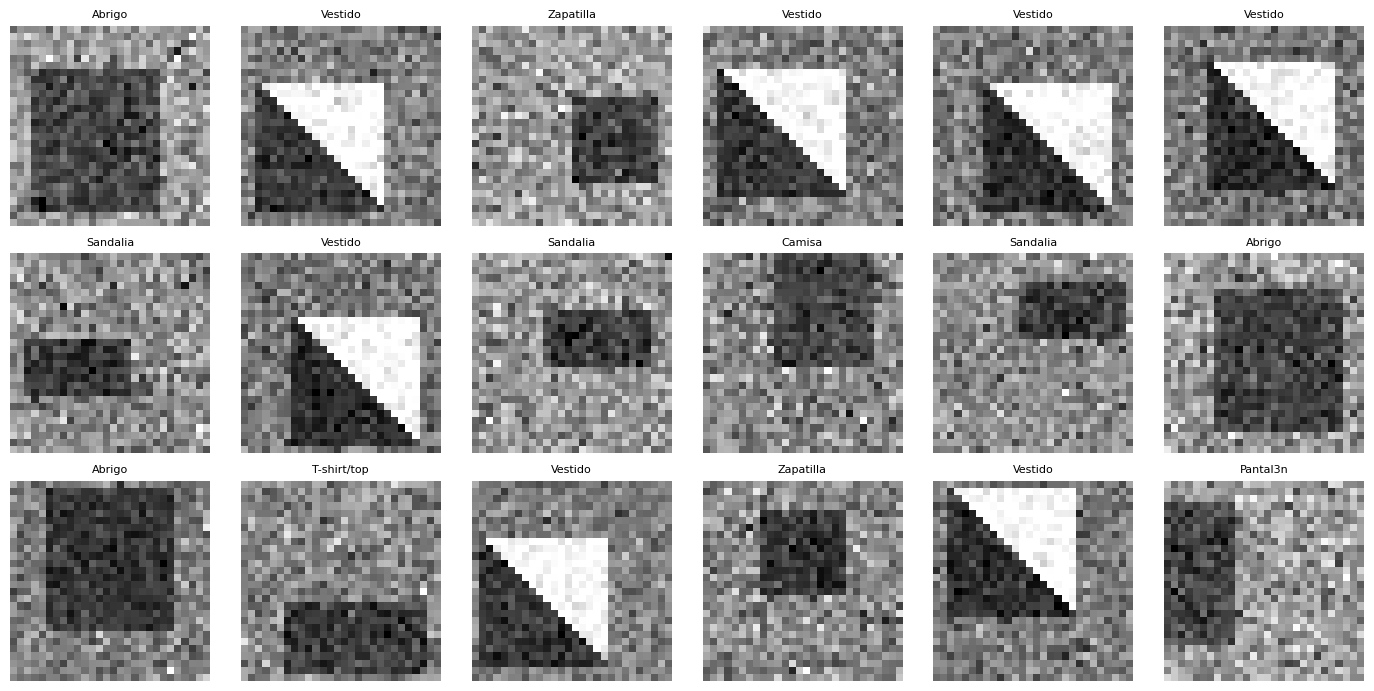

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


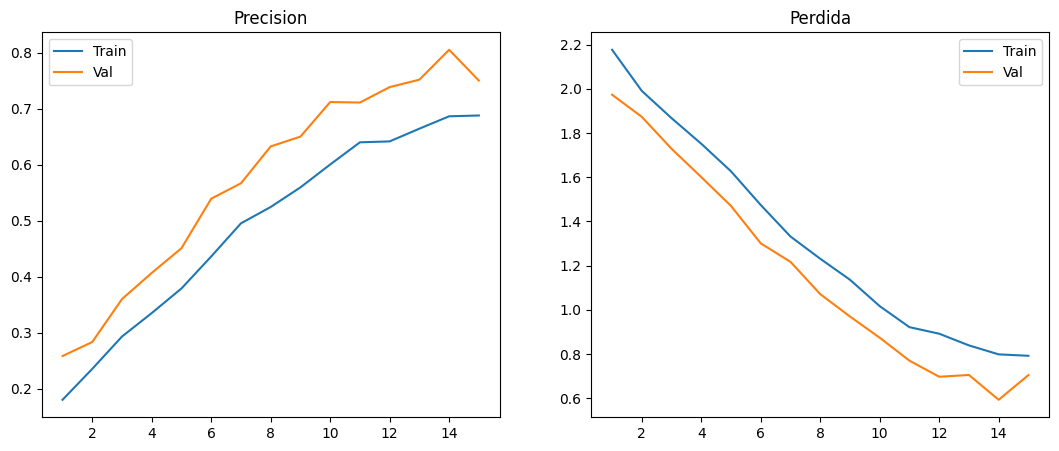

In [10]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras

# ============================================================
# CARGA Y EXPLORACI3N DEL DATASET Fashion MNIST
# ============================================================
np.random.seed(42)
N_TRAIN, N_TEST = 6000, 1000

def generar_prenda(clase, n):
    imgs = np.random.randn(n, 28, 28) * 30 + 128
    patrones = {
        0: lambda: np.ones((10, 20)) * 200, 1: lambda: np.ones((20, 10)) * 200,
        2: lambda: np.ones((15, 15)) * 200, 3: lambda: np.tril(np.ones((18, 18))) * 200,
        4: lambda: np.ones((20, 18)) * 200, 5: lambda: np.ones((8, 15)) * 200,
        6: lambda: np.ones((16, 14)) * 180, 7: lambda: np.ones((12, 12)) * 200,
        8: lambda: np.ones((14, 10)) * 200, 9: lambda: np.ones((18, 10)) * 200,
    }
    p = patrones[clase]()
    ph, pw = p.shape
    for i in range(n):
        r, c = np.random.randint(0, 28-ph), np.random.randint(0, 28-pw)
        imgs[i, r:r+ph, c:c+pw] = p + np.random.randn(ph, pw) * 20
    return np.clip(imgs, 0, 255).astype(np.uint8)

X_train_list, y_train_list, X_test_list, y_test_list = [], [], [], []
for cls in range(10):
    X_train_list.append(generar_prenda(cls, N_TRAIN // 10))
    y_train_list.extend([cls] * (N_TRAIN // 10))
    X_test_list.append(generar_prenda(cls, N_TEST // 10))
    y_test_list.extend([cls] * (N_TEST // 10))

X_train, y_train = np.concatenate(X_train_list), np.array(y_train_list)
X_test, y_test = np.concatenate(X_test_list), np.array(y_test_list)
idx_tr = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx_tr], y_train[idx_tr]
nombres_clases = ['T-shirt/top', 'Pantal3n', 'Su1ter', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

X_train_norm, X_test_norm = X_train / 255.0, X_test / 255.0

# Visualizaci3n de muestras
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
indices = np.random.choice(len(X_train), 18, replace=False)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray_r')
    ax.set_title(nombres_clases[y_train[idx]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('ejercicio2_muestras.png', dpi=150)
plt.show()

# Modelo
modelo = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
historial = modelo.fit(X_train_norm, y_train, epochs=15, batch_size=64, validation_split=0.2, verbose=0)

# Gr1fica de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
epocas = range(1, len(historial.history['accuracy']) + 1)
ax1.plot(epocas, historial.history['accuracy'], label='Train'); ax1.plot(epocas, historial.history['val_accuracy'], label='Val')
ax1.set_title('Precision'); ax1.legend()
ax2.plot(epocas, historial.history['loss'], label='Train'); ax2.plot(epocas, historial.history['val_loss'], label='Val')
ax2.set_title('Perdida'); ax2.legend()
plt.savefig('ejercicio2_entrenamiento.png', dpi=150)
plt.show()

## Ejercicio 3

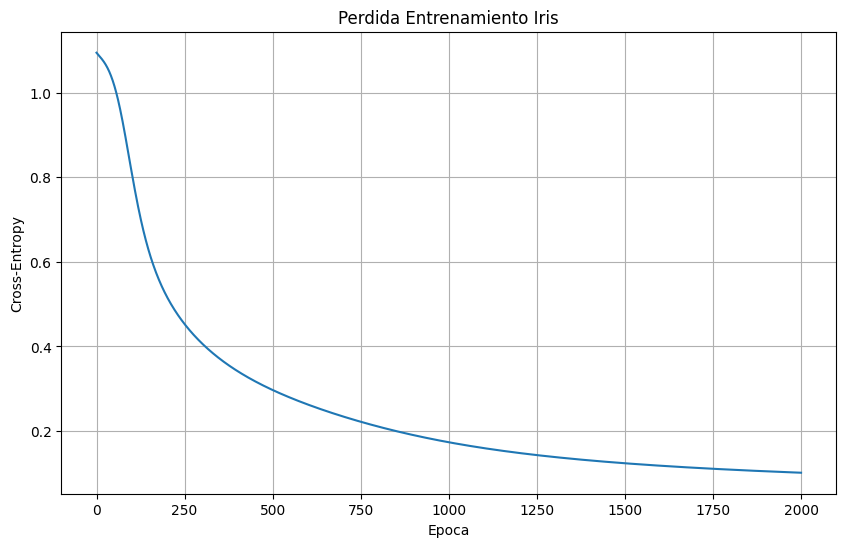

Gráfica Iris generada.


In [11]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Datos
iris = load_iris()
X_raw, y_raw = iris.data, iris.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

def one_hot(y, n_clases):
    Y = np.zeros((len(y), n_clases))
    Y[np.arange(len(y)), y] = 1
    return Y

Y_onehot = one_hot(y_raw, 3)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_onehot, test_size=0.3, random_state=42)

# Funciones RNA
def sig(s): return 1 / (1 + np.exp(-s))
def dSig(s): return sig(s) * (1 - sig(s))
def softmax(s):
    exp_s = np.exp(s - np.max(s, axis=0, keepdims=True))
    return exp_s / np.sum(exp_s, axis=0, keepdims=True)

# Red Neuronal Simple (Arquitectura 4 -> 8 -> 3)
np.random.seed(42)
W1 = np.random.randn(8, 4) * 0.1; b1 = np.zeros((8, 1))
W2 = np.random.randn(3, 8) * 0.1; b2 = np.zeros((3, 1))

historial_error = []
eta = 0.1
for epoca in range(2000):
    # Propaga
    Z1 = W1 @ X_train.T + b1; A1 = sig(Z1)
    Z2 = W2 @ A1 + b2; A2 = softmax(Z2)
    # Error
    loss = -np.mean(np.sum(Y_train.T * np.log(A2 + 1e-8), axis=0))
    historial_error.append(loss)
    # Backprop
    dZ2 = A2 - Y_train.T
    dW2 = dZ2 @ A1.T / X_train.shape[0]
    db2 = np.mean(dZ2, axis=1, keepdims=True)
    dZ1 = (W2.T @ dZ2) * dSig(Z1)
    dW1 = dZ1 @ X_train / X_train.shape[0]
    db1 = np.mean(dZ1, axis=1, keepdims=True)
    # Update
    W2 -= eta * dW2; b2 -= eta * db2
    W1 -= eta * dW1; b1 -= eta * db1

# Visualizaci3n
plt.figure(figsize=(10,6))
plt.plot(historial_error)
plt.title('Perdida Entrenamiento Iris')
plt.xlabel('Epoca'); plt.ylabel('Cross-Entropy')
plt.grid(True)
plt.savefig('ejercicio3_iris.png', dpi=150)
plt.show()
print("Gráfica Iris generada.")